# pyXSIM Simulation of a TNG Galaxy

This notebook shows how we can use [pyXSIM](https://hea-www.cfa.harvard.edu/~jzuhone/pyxsim/) to create a mock X-ray observation of a galaxy from TNG50 (using also yt and SOXS).

We tailor this example to the "Light Element Mapper" (LEM) mission, but this can be changed to any other X-ray instrument supported by pyXSIM.

<div style='border: 1px solid red; width: auto; padding: 10px;'><b>NOTE:</b> In general, the use of yt with Illustris, IllustrisTNG, or simulations run with AREPO in general is <b>not recommended</b>. 
<br>The developers of these simulations do not frequently use yt, and therefore support may be lacking or incomplete. Bugs and incorrect calculations may occur.
<br>You should carefully consider the correctness of all results. </div>

First, we need to install pyXSIM into your Lab environment:

In [ ]:
!pip install pyxsim

After a successful installation, we first import SOXS, which will download some data files:

In [ ]:
from soxs.utils import soxs_cfg
soxs_cfg.set("soxs", "bkgnd_nH", "0.018") # avoid configparser error by specifying here
import soxs

Then we import the remaining needed modules:

In [5]:
import yt
import pyxsim

import h5py
import numpy as np
import illustris_python as il

import os
from regions import RectangleSkyRegion
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy import wcs
from astropy.io import fits

## Pick a galaxy, load the data, and prepare it for yt

Specify the simulation, redshift, subhalo ID of a galaxy of interest:

In [6]:
basePath = "../sims.TNG/TNG50-1/output/"
snap = 99
haloID = 65 # with central subhalo ID 425719

halo = il.groupcat.loadSingle(basePath, snap, haloID=haloID)

Then load the data, where we load from the entire FoF halo (and not just the central subhalo), to include as much surrounding material as easily possible:

In [13]:
fields = ['Coordinates','GFM_CoolingRate','Density','InternalEnergy','ElectronAbundance','StarFormationRate']
gas = il.snapshot.loadHalo(basePath, snap, haloID, 'gas')
header = il.groupcat.loadHeader(basePath, snap)

with h5py.File(il.snapshot.snapPath(basePath, snap),'r') as f:
    header_snap = dict(f['Header'].attrs)

Then, since `yt` interfaces easiest with a "snapshot file", we quickly save this data to a temporary file:

In [16]:
filename = "halo_%d.hdf5" % haloID
with h5py.File(filename,'w') as f:
    for key in gas.keys():
        f['PartType0/' + key] = gas[key]
        
    # some metadata that yt demands
    f.create_group('Header')
    f['Header'].attrs['NumFilesPerSnapshot'] = 1
    f['Header'].attrs['MassTable'] = header_snap['MassTable']
    f['Header'].attrs['BoxSize'] = header['BoxSize']
    f['Header'].attrs['Time'] = header['Time']
    f['Header'].attrs['NumPart_ThisFile'] = np.array([gas['count'],0,0,0,0,0])
    
    # Must have the next six for correct units
    f["Header"].attrs["HubbleParam"] = header["HubbleParam"]
    f["Header"].attrs["Omega0"] = header["Omega0"]
    f["Header"].attrs["OmegaLambda"] = header["OmegaLambda"]

    # These correspond to the values from the TNG simulations
    f["Header"].attrs["UnitLength_in_cm"] = header_snap['UnitLength_in_cm']
    f["Header"].attrs["UnitMass_in_g"] = header_snap['UnitMass_in_g']
    f["Header"].attrs["UnitVelocity_in_cm_per_s"] = header_snap['UnitVelocity_in_cm_per_s']

## Load the data into yt

Then, we can load the data with `yt`:

In [80]:
ds = yt.load(filename)

yt : [INFO     ] 2022-02-24 16:20:10,483 Redshift is not set in Header. Assuming z=0.
yt : [INFO     ] 2022-02-24 16:20:10,485 Omega Lambda is 0.0, so we are turning off Cosmology.
yt : [INFO     ] 2022-02-24 16:20:10,487 Assuming length units are in kpc (physical)
yt : [INFO     ] 2022-02-24 16:20:10,597 Parameters: current_time              = 0.9999999999999998
yt : [INFO     ] 2022-02-24 16:20:10,598 Parameters: domain_dimensions         = [1 1 1]
yt : [INFO     ] 2022-02-24 16:20:10,599 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2022-02-24 16:20:10,600 Parameters: domain_right_edge         = [35000. 35000. 35000.]
yt : [INFO     ] 2022-02-24 16:20:10,602 Parameters: cosmological_simulation   = 0


Then, we make a phase space cut on the gas to make sure that we are focusing on the X-ray emitting gas. 
The best way to do that is with a “particle filter” in yt.

In [81]:
def hot_gas(pfilter, data):
    pfilter1 = data[pfilter.filtered_type, "temperature"] > 3.0e5
    pfilter2 = data["PartType0", "StarFormationRate"] == 0.0
    pfilter3 = data["PartType0", "GFM_CoolingRate"] < 0.0
    return (pfilter1 & pfilter2) & pfilter3

yt.add_particle_filter("hot_gas", function=hot_gas,
                       filtered_type='gas', requires=["temperature","density"])

yt : [WARNING  ] 2022-02-24 16:20:14,791 The hot_gas particle filter already exists. Overriding.


Add the particle filter to the dataset:

In [82]:
ds.add_particle_filter("hot_gas")

yt : [INFO     ] 2022-02-24 16:20:16,017 Allocating for 2.836e+06 particles
Initializing coarse index : 100%|██████████| 11/11 [00:00<00:00, 18.94it/s]
yt : [INFO     ] 2022-02-24 16:20:16,693 Updating index_order2 from 2 to 4
Initializing refined index: 100%|██████████| 11/11 [00:01<00:00,  7.28it/s]


True

## Quickly visualize the gas in the halo

We can get the subhalo position from the info we grabbed earlier:

In [62]:
c = ds.arr([halo["GroupPos"][0], halo["GroupPos"][1], halo["GroupPos"][2]], "code_length")

Just to get a sense of what things look like, make a projection plot of the total gas density:

yt : [INFO     ] 2022-02-24 16:20:31,557 xlim = 24591.064453 24991.064453
yt : [INFO     ] 2022-02-24 16:20:31,559 ylim = 19245.529297 19645.529297
yt : [INFO     ] 2022-02-24 16:20:31,561 xlim = 24591.064453 24991.064453
yt : [INFO     ] 2022-02-24 16:20:31,561 ylim = 19245.529297 19645.529297
yt : [INFO     ] 2022-02-24 16:20:31,579 Making a fixed resolution buffer of (('gas', 'density')) 800 by 800
yt : [WARNING  ] 2022-02-24 16:20:36,890 Plotting ('gas', 'density'): Wide range and zeros.
yt : [WARNING  ] 2022-02-24 16:20:36,892 Switching to symlog colorbar scaling.



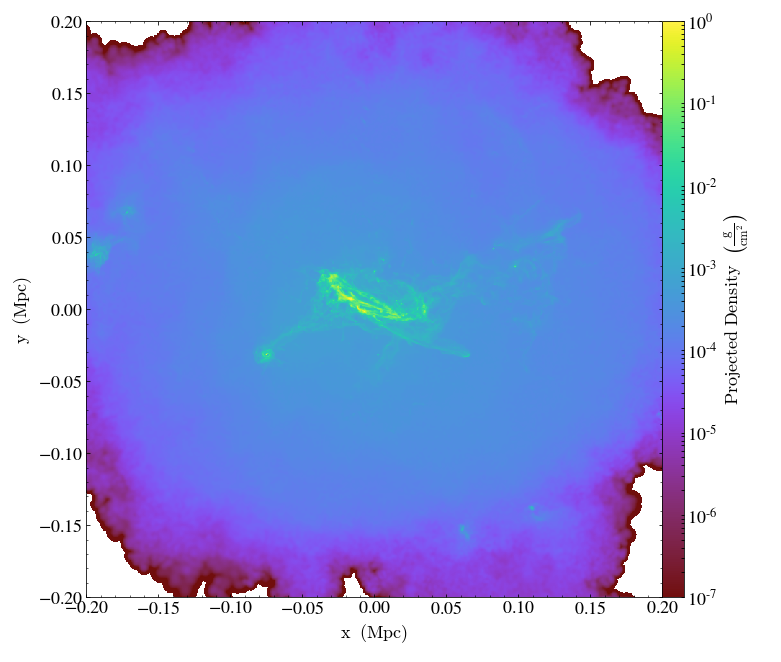

In [83]:
prj = yt.ProjectionPlot(ds, "z", ("gas","density"), width=(0.4, "Mpc"), center=c)
prj.set_zlim(("gas","density"), 1.0e-7, 1.0)

And show the same plot of the "hot" gas density:

yt : [INFO     ] 2022-02-24 16:20:41,002 xlim = 24591.064453 24991.064453
yt : [INFO     ] 2022-02-24 16:20:41,003 ylim = 19245.529297 19645.529297
yt : [INFO     ] 2022-02-24 16:20:41,005 xlim = 24591.064453 24991.064453
yt : [INFO     ] 2022-02-24 16:20:41,006 ylim = 19245.529297 19645.529297
yt : [INFO     ] 2022-02-24 16:20:41,025 Making a fixed resolution buffer of (('hot_gas', 'density')) 800 by 800
yt : [WARNING  ] 2022-02-24 16:20:50,824 Plotting ('hot_gas', 'density'): Wide range and zeros.
yt : [WARNING  ] 2022-02-24 16:20:50,826 Switching to symlog colorbar scaling.



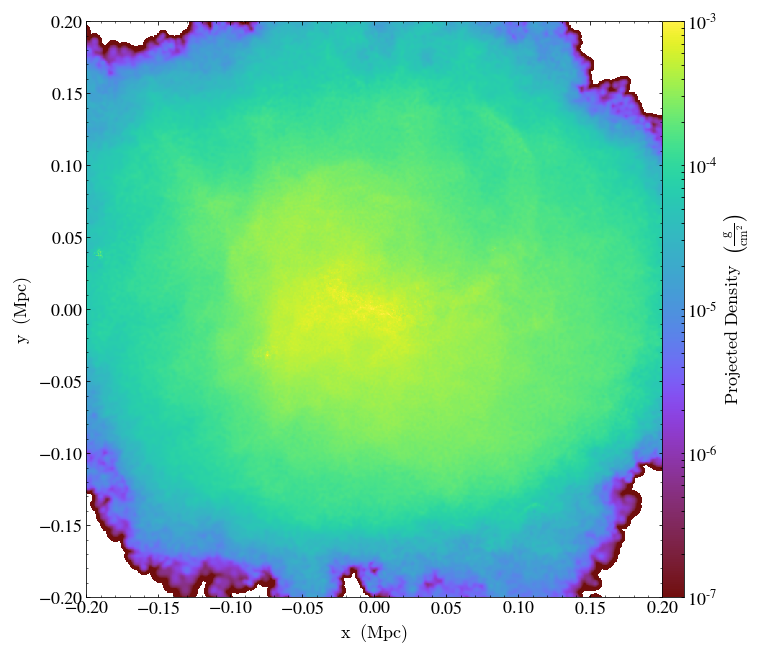

In [84]:
prj = yt.ProjectionPlot(ds, "z", ("hot_gas","density"), width=(0.4, "Mpc"), center=c)
prj.set_zlim(("hot_gas","density"), 1.0e-7, 1.0e-3)

## Configure the x-ray emission, and observation, models

Now, in order to make the mock observation, we have to set up a `ThermalSourceModel` in pyXSIM, telling it which fields to use from the dataset, and the min, max, and binning of the spectrum:

In [86]:
emin = 0.05
emax = 4.0
nbins = 4000
source_model = pyxsim.ThermalSourceModel(
    "apec", emin, emax, nbins, ("hot_gas","metallicity"),
    temperature_field=("hot_gas","temperature"),
    emission_measure_field=("hot_gas", "emission_measure"),
)

Now we specify fiducial values of the exposure time, collecting area, and redshift of the object. NOTE that the "area" here is not the effective area of the telescope--this is just a parameter that we need to decide how many sample photons to make. This number should be bigger than the peak of the telescope+instrument effective area curve.

In [87]:
exp_time = (500., "ks") # exposure time
area = (5000.0, "cm**2") # collecting area
redshift = 0.025

Now create a box centered on the galaxy, 1 Mpc in width, which will be used to draw the Arepo cells to make the photons.

In [88]:
width = ds.quan(1.0, "Mpc")
le = c - 0.5*width
re = c + 0.5*width
box = ds.box(le, re)

## Generate the mock x-ray emission

Now we actually make the photons:

In [89]:
n_photons, n_cells = pyxsim.make_photons(f"halo_{haloID}_photons", box, redshift, area, exp_time, source_model)

pyxsim : [INFO     ] 2022-02-24 16:20:56,436 Cosmology: h = 0.71 100*km/(Mpc*s), omega_matter = 0.27, omega_lambda = 0.73
pyxsim : [INFO     ] 2022-02-24 16:20:56,438 Using emission measure field '('hot_gas', 'emission_measure')'.
pyxsim : [INFO     ] 2022-02-24 16:20:56,439 Using temperature field '('hot_gas', 'temperature')'.


Preparing spectrum table :   0%|          | 0/201 [00:00<?, ?it/s]

Processing cells/particles :   0%|          | 0/1864088 [00:00<?, ?it/s]

pyxsim : [INFO     ] 2022-02-24 16:22:56,945 Finished generating photons.
pyxsim : [INFO     ] 2022-02-24 16:22:56,947 Number of photons generated: 15003064
pyxsim : [INFO     ] 2022-02-24 16:22:56,948 Number of cells with photons: 1476678


Now we project the photons, also including foreground galactic absorption. We project along the "z"-axis of the simulation box.

In [73]:
n_events = pyxsim.project_photons(f"halo_{haloID}_photons", f"halo_{haloID}_events", "z", (45.,30.),
                                  absorb_model="wabs", nH=0.01)

pyxsim : [INFO     ] 2022-02-24 16:15:48,217 Foreground galactic absorption: using the wabs model and nH = 0.01.
Projecting photons from cells/particles: 100%|██████████| 1476959/1476959 [00:42<00:00, 34953.00it/s] 
pyxsim : [INFO     ] 2022-02-24 16:16:30,587 Detected 591729 events.


Open the file containing the projected events, and convert it to SIMPUT format. 

In [74]:
events = pyxsim.EventList(f"halo_{haloID}_events.h5")
events.write_to_simput(f"halo_{haloID}", overwrite=True)

soxs : [INFO     ] 2022-02-24 16:16:37,452 Writing source to halo_65_phlist.fits.


## Create a synthetic observation of these x-rays with LEM

We can now use this SIMPUT catalog to make a mock LEM observation. For now, we turn off the astrophysical background from the galaxy, and distant point sources.

In [75]:
instrument = "lem"
soxs.instrument_simulator(f"halo_{haloID}_simput.fits", f"halo_{haloID}_evt.fits", (500.0, "ks"), instrument, (45.,30.), overwrite=True, foreground=False, ptsrc_bkgnd=False)

soxs : [INFO     ] 2022-02-24 16:17:19,880 Making observation of source in halo_65_evt.fits.
100%|█████████████████████████████████████| 46.1k/46.1k [00:00<00:00, 22.2MB/s]
100%|███████████████████████████████████████| 213k/213k [00:00<00:00, 87.7MB/s]
soxs : [INFO     ] 2022-02-24 16:17:21,798 Detecting events from source halo_65
soxs : [INFO     ] 2022-02-24 16:17:21,799 Applying energy-dependent effective area from lem.arf.
soxs : [INFO     ] 2022-02-24 16:17:21,865 239375 events detected.
soxs : [INFO     ] 2022-02-24 16:17:21,873 Pixeling events.
soxs : [INFO     ] 2022-02-24 16:17:21,962 Scattering events with a gaussian-based PSF.
soxs : [INFO     ] 2022-02-24 16:17:21,992 0 events were rejected because they do not fall on any CCD.
soxs : [INFO     ] 2022-02-24 16:17:22,015 Scattering energies with RMF lem.rmf.


Scattering energies :   0%|          | 0/239375 [00:00<?, ?it/s]

soxs : [INFO     ] 2022-02-24 16:17:23,067 Adding background events.
soxs : [INFO     ] 2022-02-24 16:17:23,191 Writing events to file halo_65_evt.fits.
soxs : [INFO     ] 2022-02-24 16:17:23,352 Observation complete.


This produces an event file, which we now convert to an image and show. The green square in the image shows the FOV of LEM. 

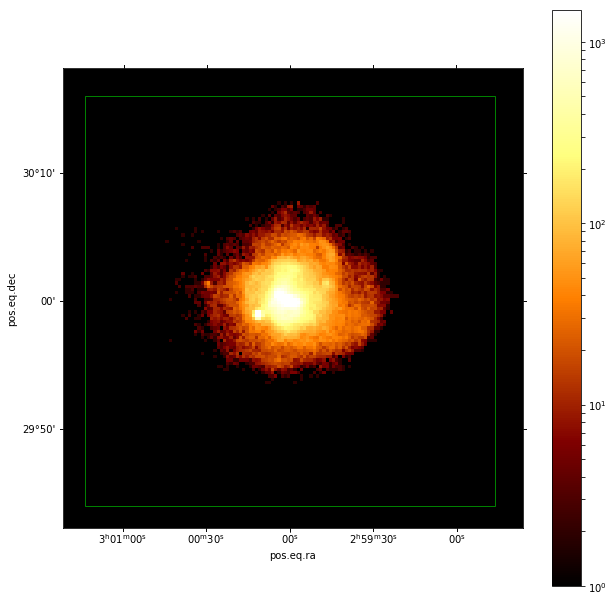

In [76]:
soxs.write_image(f"halo_{haloID}_evt.fits", f"halo_{haloID}_img.fits", emin=0.1, emax=2.0, overwrite=True)
center_sky = SkyCoord(45, 30, unit='deg', frame='fk5')
region_sky = RectangleSkyRegion(center=center_sky, width=32 * u.arcmin, height=32*u.arcmin)
with fits.open(f"halo_{haloID}_img.fits") as f:
    w = wcs.WCS(header=f[0].header)
    fig, ax = soxs.plot_image(f"halo_{haloID}_img.fits", stretch='log', cmap='afmhot', vmax=1500.0, width=0.6)
ax.add_artist(region_sky.to_pixel(w).as_artist())

We can also make and plot a spectrum:

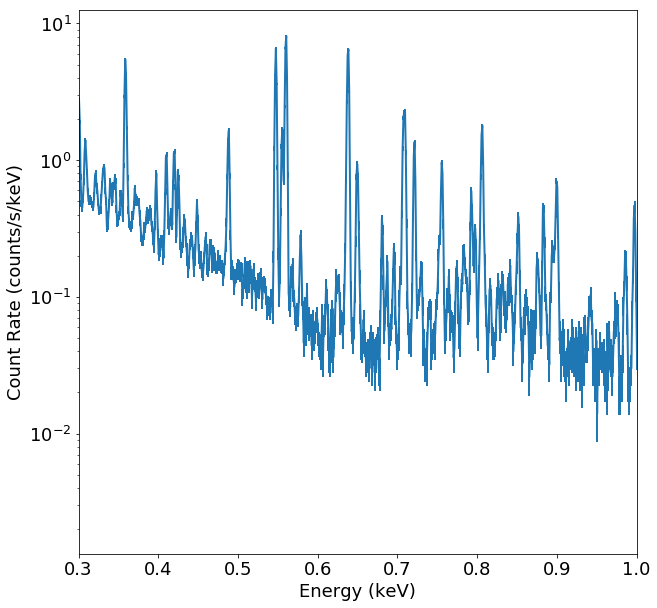

In [77]:
soxs.write_spectrum(f"halo_{haloID}_evt.fits", f"halo_{haloID}_evt.pi", overwrite=True)
fig, ax = soxs.plot_spectrum(f"halo_{haloID}_evt.pi", xmin=0.3, xmax=1.0, xscale="linear")

That's it! Thanks to John ZuHone for preparing the original walkthrough for the LEM workshop in Feb 2022.

Please address any questions/comments to John ZuHone and Dylan Nelson.